# Proyek Analisis Data: E-commerce-public-dataset
- **Nama:** Tria Amalia Anasya
- **Email:** cdcc409d6x2388@student.devacademy.id
- **ID Dicoding:** CDCC409D6X2388

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : kategori produk apa yang paling banyak terjual?
- Pertanyaan 2 : Bagaimana tren penjualan dari waktu ke waktu?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import datetime as dt
import warnings

from matplotlib.ticker import FuncFormatter
import missingno as msno
import plotly.express as px

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
plt.style.use('seaborn-v0_8')

## Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.listdir('/content/drive/MyDrive/E-Commerce Public Dataset')

['order_payments_dataset.csv',
 'order_reviews_dataset.csv',
 'geolocation_dataset.csv',
 'New Text Document.txt',
 'customers_dataset.csv',
 'order_items_dataset.csv',
 'product_category_name_translation.csv',
 'orders_dataset.csv',
 'products_dataset.csv',
 'sellers_dataset.csv',
 'orders_datasett.csv']

## Data Wrangling

### Gathering Data

In [4]:
orders = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/orders_dataset.csv')
customers = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/customers_dataset.csv')
products = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/products_dataset.csv')
sellers = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/sellers_dataset.csv')
order_items = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/order_items_dataset.csv')
payments = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/order_payments_dataset.csv')
reviews = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/order_reviews_dataset.csv')
geolocation = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/geolocation_dataset.csv')
category = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/product_category_name_translation.csv')

**Insight:**
- Dataset terdiri dari beberapa tabel seperti orders, customers, products, dan lainnya yang saling terhubung melalui ID.
- Data bersifat relasional dan mencakup berbagai aspek transaksi e-commerce sehingga perlu digabungkan untuk analisis lebih lanjut.

### Assessing Data

In [5]:
# Info
orders.info()
customers.info()
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null 

In [6]:
# Missing value
orders.isnull().sum()
customers.isnull().sum()
products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [7]:
# duplicate
orders.duplicated().sum()
customers.duplicated().sum()

np.int64(0)

saya mengecek kondisi data untuk melihat apakah ada missing values atau data yang duplikat. Di sini terlihat ada beberapa kolom waktu dan detail produk yang belum lengkap.

In [8]:
# Statistik
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Insight:**
- Ditemukan missing value pada beberapa kolom, terutama pada dataset products (seperti product_category_name dan atribut produk lainnya) serta pada kolom waktu di dataset orders.
- Tidak ditemukan data duplikat pada dataset orders dan customers, namun terdapat ketidaksesuaian tipe data terutama pada kolom timestamp yang masih bertipe object.

### Cleaning Data

tahap ini saya memperbaiki data yang kurang rapi seperti kolom waktu yang tadinya berupa teks diubah menjadi format tanggal yang benar.
Data produk yang kosong diisi menggunakan median atau dihapus jika memang tidak bisa digunakan agar hasil analisis akurat.

In [9]:
# Convert tipe data ke datatime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [10]:
# Handle Missing value dgn median
products['product_weight_g'].fillna(products['product_weight_g'].median(), inplace=True)
products['product_length_cm'].fillna(products['product_length_cm'].median(), inplace=True)
products['product_height_cm'].fillna(products['product_height_cm'].median(), inplace=True)
products['product_width_cm'].fillna(products['product_width_cm'].median(), inplace=True)

# drop kolom yang missingnya banyak
products.dropna(subset=[
    'product_category_name',
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty'
], inplace=True)

**Insight:**
- Tipe data pada kolom timestamp berhasil dikonversi dari object menjadi datetime untuk memudahkan analisis berbasis waktu.
- Missing value telah ditangani menggunakan metode imputasi dan penghapusan data sehingga kualitas data menjadi lebih baik dan siap digunakan.

## Exploratory Data Analysis (EDA)

### Explore ...

In [11]:
# menggabungkan tabel orders_items dengan product dan category
product_counts = pd.merge(order_items, products, on='product_id', how='left')
product_counts = pd.merge(product_counts, category, on='product_category_name', how='left')

# hitung jumlah terjual per category
top_categories = product_counts.groupby('product_category_name_english')['order_id'].count().sort_values(ascending=False).head(10)

print(top_categories)

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = orders.groupby('year_month')['order_id'].count()

print(monthly_orders.head())

product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: order_id, dtype: int64
year_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
Freq: M, Name: order_id, dtype: int64


In [12]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = orders.groupby('year_month')['order_id'].count()

monthly_orders

,order_id
year_month,
2016-09,4
2016-10,324
2016-12,1
2017-01,800
2017-02,1780
2017-03,2682
2017-04,2404
2017-05,3700
2017-06,3245


**Insight:**
- Jumlah pesanan mengalami peningkatan signifikan dari tahun 2016 hingga mencapai puncak pada November 2017
- Setelah itu, tren penjualan cenderung stabil pada tahun 2018 meskipun terdapat penurunan tajam di akhir periode

## Visualization & Explanatory Analysis

### Pertanyaan 1:

saya mencari kategori produk apa yang paling laku. Dengan menggabungkan data transaksi dan kategori produk, saya bisa melihat produk mana saja yang menjadi favorit pelanggan.

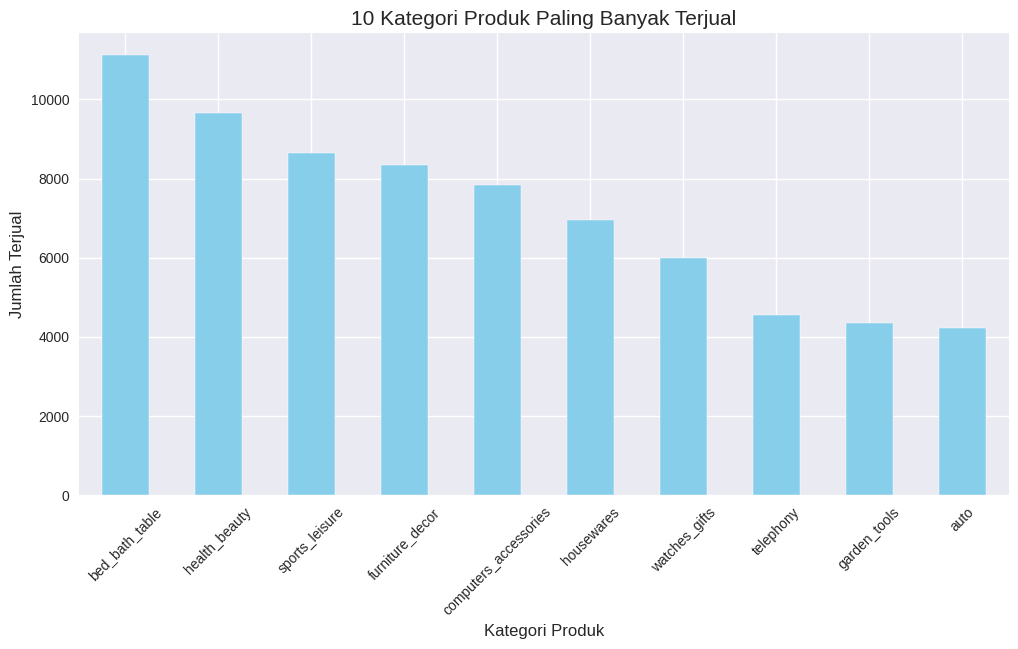

In [13]:
# 1. gabungkan data agar tahu nama kategori produknya
product_counts = pd.merge(order_items, products, on='product_id', how='left')
product_counts = pd.merge(product_counts, category, on='product_category_name', how='left')

# 2. menghitung jumlah terjual per kategori dgn mengambil 10 baris pertama
top_categories = product_counts.groupby('product_category_name_english')['order_id'].count().sort_values(ascending=False).head(10)

# 3. visualisasi
plt.figure(figsize=(12, 6))
top_categories.plot(kind='bar', color='skyblue')
plt.title('10 Kategori Produk Paling Banyak Terjual', fontsize=15)
plt.xlabel('Kategori Produk', fontsize=12)
plt.ylabel('Jumlah Terjual', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### Pertanyaan 2:

Disini saya melihat perkembangan pesanan dari waktu ke waktu. Hal ini bertujuan untuk melihat kapan penjualan naik paling tinggi dan kapan mulai stabil atau menurun

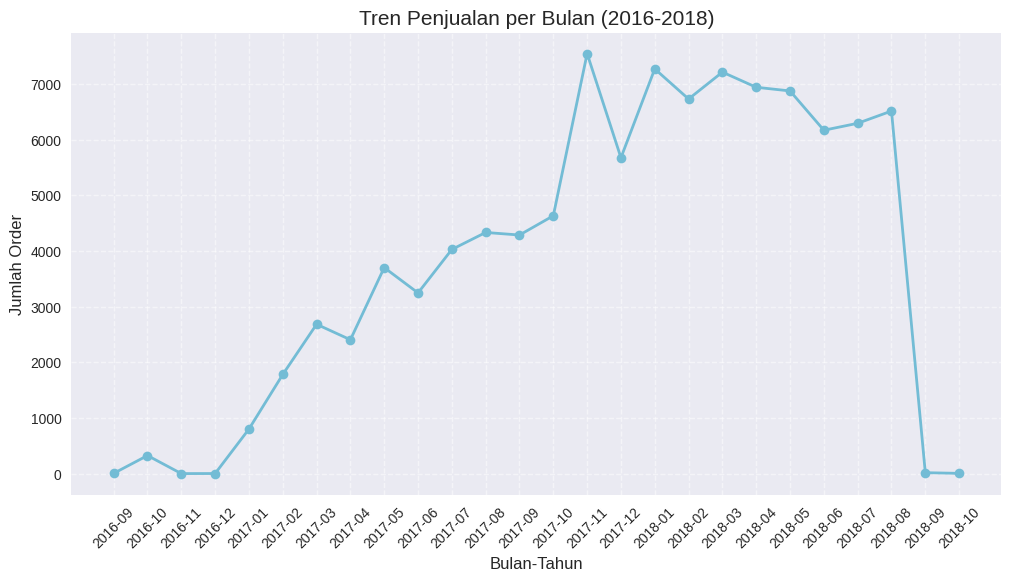

In [14]:
# 1. pastikan kolom waktu sudah bertipe datetime dan buat kolom bulan-tahun
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
monthly_orders = orders.resample(rule='M', on='order_purchase_timestamp').agg({
    "order_id": "nunique"
})
monthly_orders.index = monthly_orders.index.strftime('%Y-%m') # Mengubah format index jadi Tahun-Bulan
monthly_orders = monthly_orders.reset_index()
monthly_orders.rename(columns={"order_id": "order_count"}, inplace=True)

# 2. visualisasi tren penjualan
plt.figure(figsize=(12, 6))
plt.plot(monthly_orders['order_purchase_timestamp'], monthly_orders['order_count'], marker='o', linewidth=2, color='#73BCD5')
plt.title('Tren Penjualan per Bulan (2016-2018)', fontsize=15)
plt.xlabel('Bulan-Tahun', fontsize=12)
plt.ylabel('Jumlah Order', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Insight:**
- Berdasarkan grafik batang di atas, kategori bed_bath_table menjadi produk yang paling banyak terjual dengan total lebih dari 11.000 order, disusul oleh health_beauty dan sports_leisure. Hal ini menunjukkan bahwa kebutuhan rumah tangga dan perawatan diri merupakan penggerak utama transaksi di platform ini, sehingga perusahaan perlu memastikan ketersediaan stok dan variasi produk pada kategori-kategori tersebut tetap terjaga.
- Tren penjualan menunjukkan pertumbuhan yang sangat positif dan signifikan mulai awal tahun 2017 hingga mencapai puncaknya pada November 2017 dengan lebih dari 7.000 order, yang kemungkinan besar dipicu oleh momen promo Black Friday. Meskipun sempat mengalami fluktuasi, angka penjualan di tahun 2018 cenderung stabil di level tinggi, sementara penurunan tajam di akhir grafik (September-Oktober 2018) terindikasi sebagai keterbatasan data (cut-off) dalam dataset.

## Analisis Lanjutan (Opsional)

In [15]:
current_date = orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Gabungkan tabel orders dan order_items (hitung total harga per order dulu)
price_per_order = order_items.groupby('order_id').agg({'price': 'sum'}).reset_index()
rfm_df = pd.merge(orders, price_per_order, on='order_id', how='left')

rfm_analysis = rfm_df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (current_date - x.max()).days, # Recency
    'order_id': 'count',
    'price': 'sum'
}).reset_index()

# mengganti nama kolom
rfm_analysis.columns = ['customer_id', 'recency', 'frequency', 'monetary']

print(rfm_analysis.head())

                        customer_id  recency  frequency  monetary
0  00012a2ce6f8dcda20d059ce98491703      338          1     89.80
1  000161a058600d5901f007fab4c27140      459          1     54.90
2  0001fd6190edaaf884bcaf3d49edf079      597          1    179.99
3  0002414f95344307404f0ace7a26f1d5      428          1    149.90
4  000379cdec625522490c315e70c7a9fb      199          1     93.00


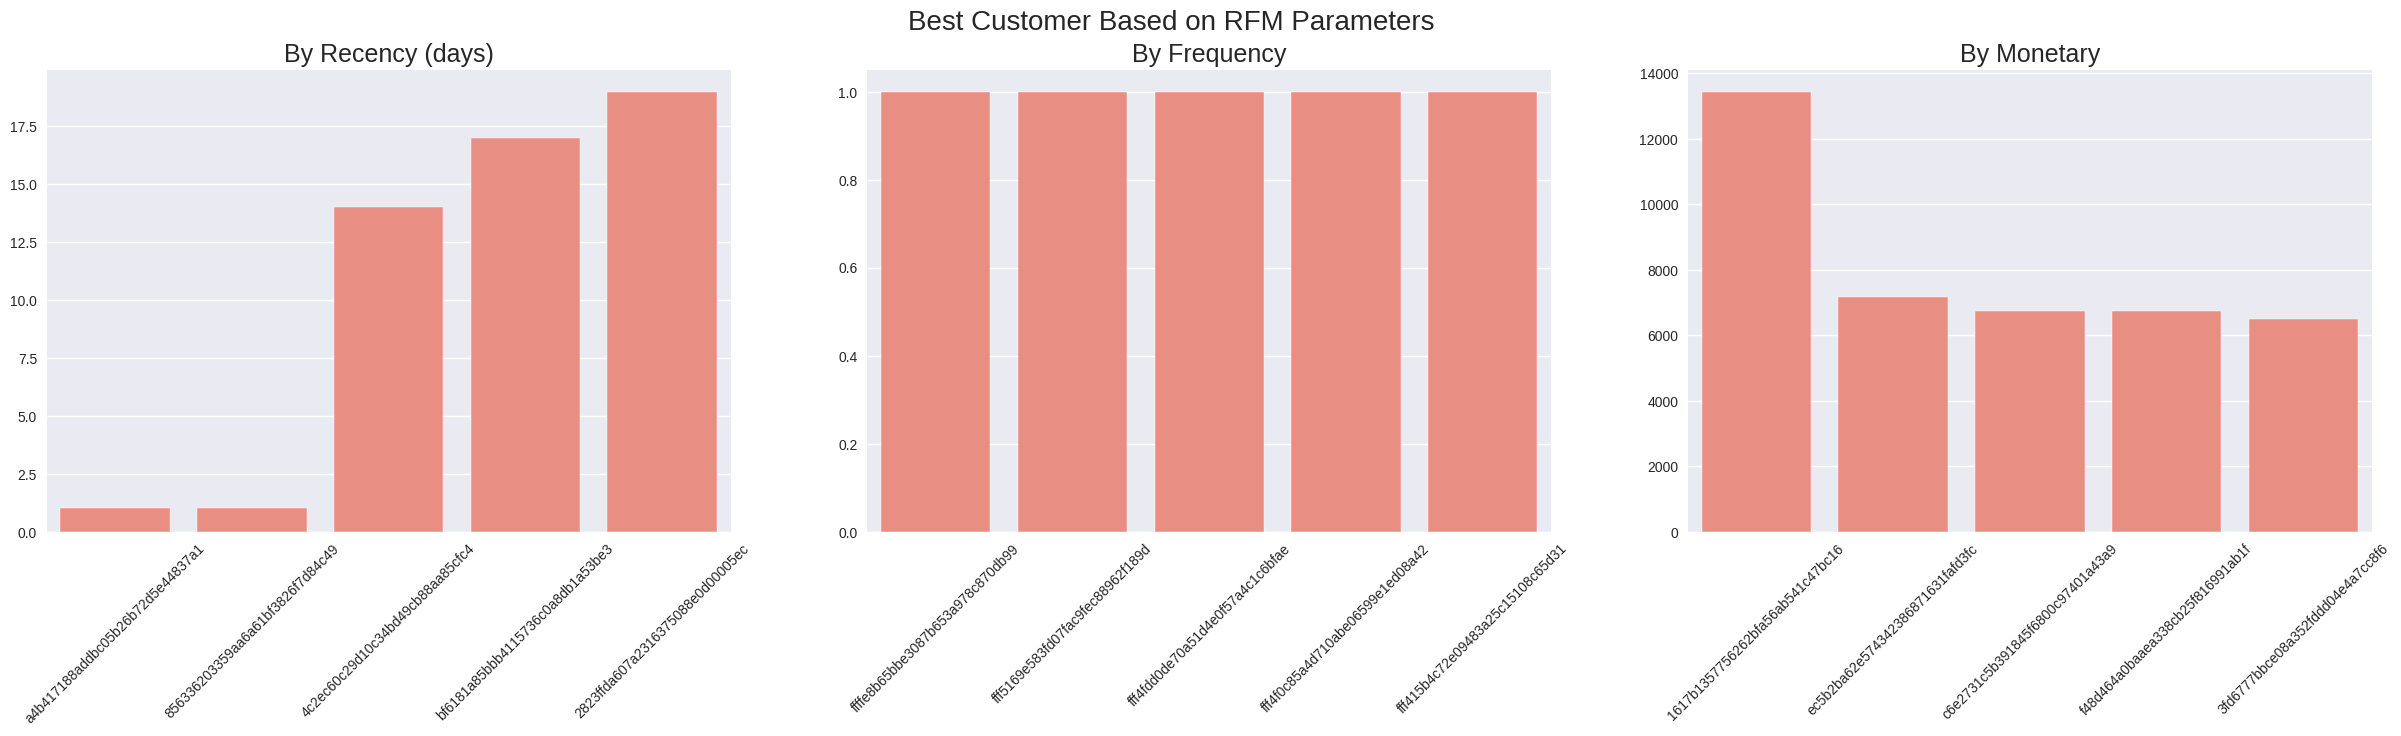

In [16]:
# Visualisasi RFM sederhana
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))

colors = ["salmon", "salmon", "salmon", "salmon", "salmon"]

# Berdasarkan Recency
sns.barplot(y="recency", x="customer_id", data=rfm_analysis.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis='x', rotation=45)

# Berdasarkan Frequency
sns.barplot(y="frequency", x="customer_id", data=rfm_analysis.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', rotation=45)

# Berdasarkan Monetary
sns.barplot(y="monetary", x="customer_id", data=rfm_analysis.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', rotation=45)

plt.suptitle("Best Customer Based on RFM Parameters", fontsize=20)
plt.show()

Saya melakukan analisis RFM untuk mengenal pelanggan lebih dalam untuk melihat
Recency: Kapan terakhir mereka belanja?,
Frequency: Seberapa sering mereka belanja?
Monetary: Berapa banyak uang yang mereka habiskan?

In [17]:
# simpan file csv rfm
rfm_analysis.to_csv("main_data.csv", index=False)

## Conclusion

- Conclusion Pertanyaan 1: Kategori produk apa yang paling banyak terjual
berdasarkan hasil analisis, kategori bed_bath_table menjadi yg utama dengan penjualan tertinggi, disusul oleh health_beauty. Hal ini menunjukkan bahwa kategori kebutuhan rumah tangga dan perawatan diri memiliki permintaan yang tinggi. Strategi bisnis ke depannya dapat difokuskan pada penambahan stok dan promo bundling untuk kategori-kategori populer ini agar bisa mempertahankan dominasi pasar.

- Conclusion Pertanyaan 2: Bagaimana tren penjualan dari waktu ke waktu?
Performa penjualan perusahaan menunjukkan tren pertumbuhan yang sangat bagus, terutama mulai awal tahun 2017. Lonjakan drastis pada November 2017 membuktikan efektivitas kampanye pemasaran. Meskipun data berakhir pada akhir 2018, stabilitas angka penjualan di tahun terakhir menunjukkan bahwa platform sudah memiliki basis pelanggan yang tetap

Laast but not least, dgn melalui teknik RFM, sebagian besar pelanggan saat ini adalah pembeli baru (high recency) namun masih bersifat onetime buyer (low frequency). Ini dapat dijadikan peluang bagi tim marketing untuk membuat program retention agar pelanggan tersebut kembali belanja.